In [138]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from astropy.io import fits

from scipy.ndimage import gaussian_filter1d

%matplotlib inline


### Degrading the original resolution from 0.88 A to 2.56 A by convolving with the Gaussian kernel :

In [139]:
def star_data(path):
    return fits.open(path)

We know that convolution of two Gaussians is also a gaussian and their variances add : 

In [ ]:
def degrade_res(star_data):
    hdr = star_data[0].header           # get the header of the primary HDU of the star FITS file 
    flux = star_data[0].data            # get the flux array for the star

    n_wave_points = len(flux)           # number of points in array

    crval = hdr["CRVAL1"]               # start value for the wavelength axis
    cdelt = hdr["CDELT1"]               # step value

    wavelength = crval  + cdelt * np.arange(n_wave_points)          # defining the wavelength array

    cflib_res_fwhm = 0.88                   # intrinsic resolution of the CFLIB library (FWHM)
    cflib_int_res_fwhm = 2.56               # resolution of the interpolated CFLIB flux (FWHM) based on MILES

    def var(res_fwhm):          # relation between variance and FWHM
        return res_fwhm/(2*np.log(2))
    
    cflib_conv_res_fwhm = ((cflib_int_res_fwhm)**2 - (cflib_res_fwhm)**2) ** 1/2            # resolution FWHM of the gaussian Kernel

    var_conv_res_fwhm = var(cflib_conv_res_fwhm)                # variance of the the FWHM of the gaussian kernel 

    var_pixel = var_conv_res_fwhm/cdelt                     # variance per pixel 

    filtered_flux = gaussian_filter1d(flux, sigma = var_pixel)          # Convolution with the gaussian Kernel to degrade the resolution

    return filtered_flux



In [141]:
data_5750 = star_data("../../FITS_data/5750.fits")

In [142]:
degraded_flux = degrade_res(data_5750)

### Resampling the data using cubic spline interpolation

In [143]:
from scipy.interpolate import CubicSpline   

In [ ]:
def resampling(wavelength, flux):

    cs = CubicSpline(wavelength, flux)          # defining the cs object

    new_wavelength = np.arange(3465,9469, 0.9)      # defining a new wavelength grid
    
    flux_resampled = cs(new_wavelength)         # applying cubic spline interpolation on the new wavelenth to get the new resampled flux

    return new_wavelength, flux_resampled

In [ ]:
wavelength = data_5750[0].header["CRVAL1"] + data_5750[0].header["CDELT1"] * np.arange(len(data_5750[0].data))  # actual wavelength grid 

new_wavelength, degraded_flux_resampled = resampling(wavelength, degraded_flux)


### Normalizing the flux axis at approx wavelength 5550 A: 

In [146]:
for i in range(len(new_wavelength)):
    if new_wavelength[i]//1 == 5550:
        print(new_wavelength[i])

5550.30000000021


In [ ]:
def normalizing(wavelength, flux):

    index = 0

    for i in range(len(wavelength)):
        if wavelength[i] == 5550.30000000021:
            index = i

    normalized_flux = flux/flux[index]              # normalizing the flux axis at approx 5550 A value of wavelength

    return normalized_flux


In [148]:
normalized_resampled_degraded_flux = normalizing(new_wavelength, degraded_flux_resampled)
normalized_resampled_degraded_flux

array([7.00068680e-01, 7.02581590e-01, 7.08017491e-01, ...,
       9.78104753e-05, 9.78104753e-05, 9.78104753e-05])

### Changing the coverage of the wavelength axis (making the new wavelength grid) : 

Getting the exact step size : 


In [150]:
range_diff = 7410.5 - 3536.0
n_pred_values = 4306
step_size = range_diff/n_pred_values
step_size


0.8997909893172318

In [ ]:
mask = (new_wavelength >= 3536.0) & (new_wavelength <= 7410.600000000399)
final_wavelength = new_wavelength[mask]         # new wavelength grid with step value of 0.9
final_flux = normalized_resampled_degraded_flux[mask]       # Flux at each wavelength in the new wavelength grid

In [151]:
len(final_wavelength)

4306

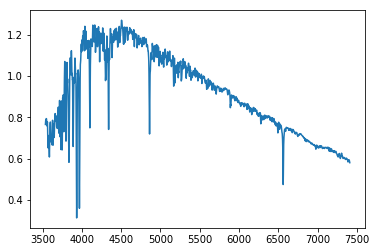

In [152]:
plt.plot(final_wavelength, final_flux)

### Comparing plots of original spectra with interpolated spectra : 

In [153]:
INTERPOLATOR_MODEL = '../RF_base_model_pvk.sav'
STANDARD_SCALER = '../rf_standard_scale_pvk.sav'

In [154]:
from sklearn.externals import joblib

sc = joblib.load(STANDARD_SCALER)
ip = joblib.load(INTERPOLATOR_MODEL)

In [155]:
ip.n_jobs = 1 

def InterpolateSpectrum(temperature, gravity, metallicity):
    X = np.array([temperature, gravity, metallicity]).reshape(1, -1)
    X_std = sc.transform(X)
    y = ip.predict(X_std)
    return y

In [156]:
pred = InterpolateSpectrum(6330,4.21,-0.42)

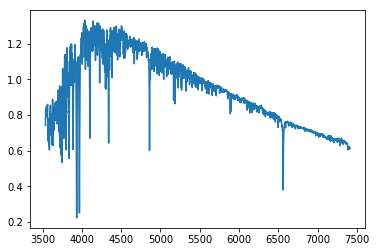

In [157]:
plt.plot(final_wavelength, pred[0,:])

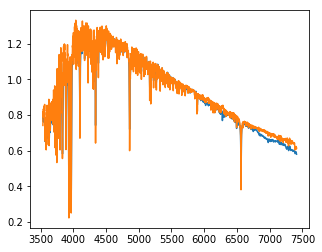

In [158]:
plt.figure(figsize= (5,4))
plt.plot(final_wavelength, final_flux)
plt.plot(final_wavelength, pred[0,:])

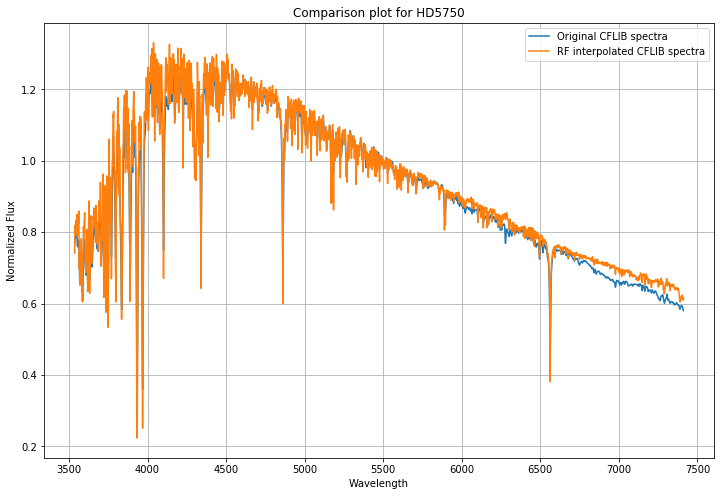

In [159]:
plt.figure(figsize=(12,8))
plt.plot(final_wavelength, final_flux, label = "Original CFLIB spectra")
plt.plot(final_wavelength, pred[0,:], label = "RF interpolated CFLIB spectra")
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.title("Comparison plot for HD5750")
plt.grid()
plt.legend()
plt.show()
